
=== Security Twin IDS Placement Experiment ===
Random seed: 42
FAST_DEMO: False

[1] Building small twin...
   Attacker: Gateway  |  Target: Database

[Small] Network Statistics
Nodes: 6
Edges: 6
Average degree: 2.00
[1a] Discovering attack paths (k-shortest)...
   Found 2 path(s) (showing up to 10):
      1: Gateway -> LoadBalancer -> AppServerA -> InternalSwitch -> Database
      2: Gateway -> LoadBalancer -> AppServerB -> InternalSwitch -> Database
[1b] Monte Carlo simulation on small twin...]
   Success rate: 0.012
   Simulation time: 0.02 seconds
   IDS budget (small): 2  | Risk-aware: {'InternalSwitch', 'LoadBalancer'}  | Random: {'AppServerA', 'InternalSwitch'}
[1c] Evaluating detection (small)...
   Detection (risk-aware): 0.396 (time 0.01s) | Detection (random): 0.069 (time 0.02s)

Top Risk Nodes
Gateway 1.0
LoadBalancer 1.0
InternalSwitch 1.0
Database 1.0
AppServerB 0.79


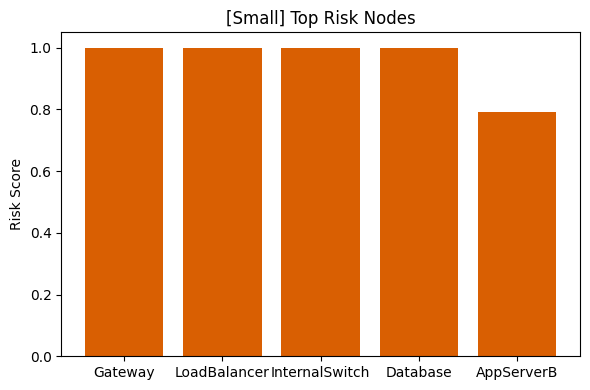

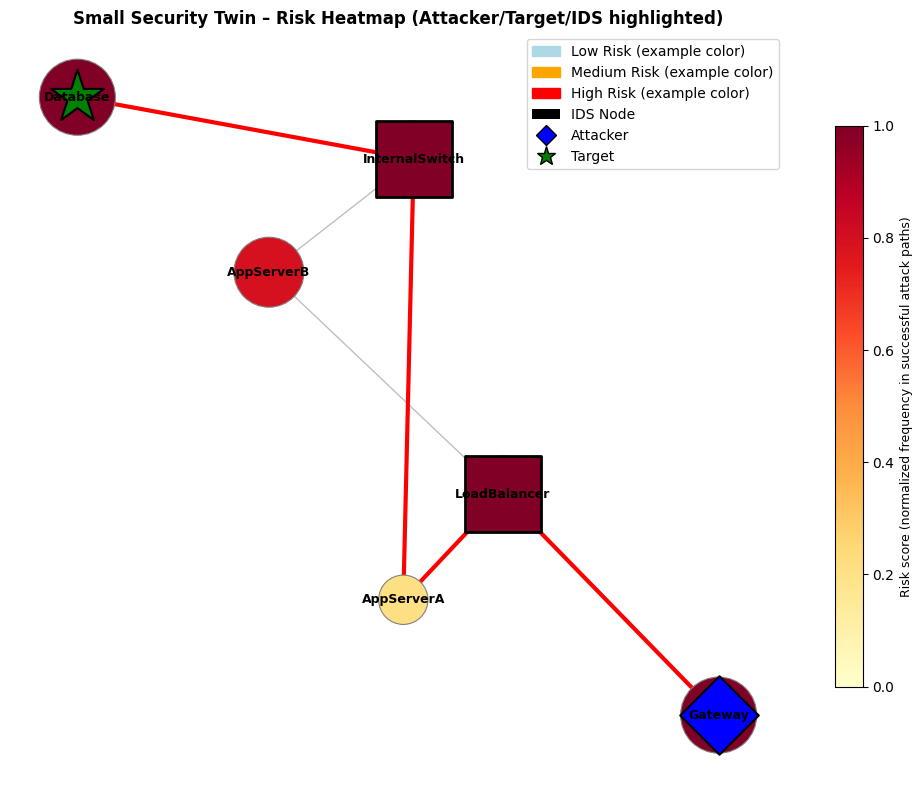


[2] Building large twin...
   Attacker: 32  |  Target: 4  | Nodes: 220  | Edges: 651

[Large] Network Statistics
Nodes: 220
Edges: 651
Average degree: 5.92
[2a] Discovering attack paths (k-shortest, limited cutoff)...
   Found 1 candidate path(s) (showing few):
      1: 32 -> 4
[2b] Monte Carlo simulation on large twin...]
   Success rate: 0.061
   Simulation time: 0.65 seconds
   IDS budget (large): 5  | Risk-aware: 5 nodes  | Random: 5 nodes
[2c] Evaluating detection (large)...
   Detection (risk-aware): 0.024 (time 0.24s) | Detection (random): 0.009 (time 0.24s)

Top Risk Nodes
4 1.0
32 1.0
0 0.0
1 0.0
2 0.0


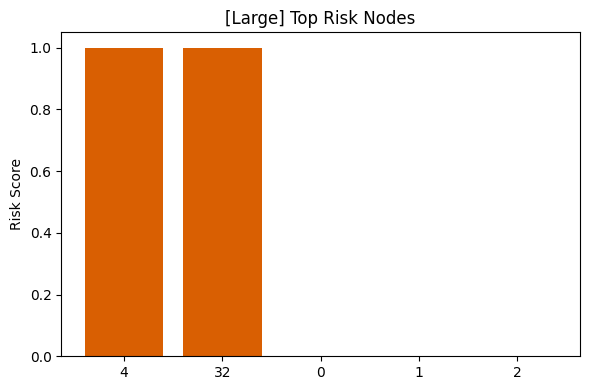

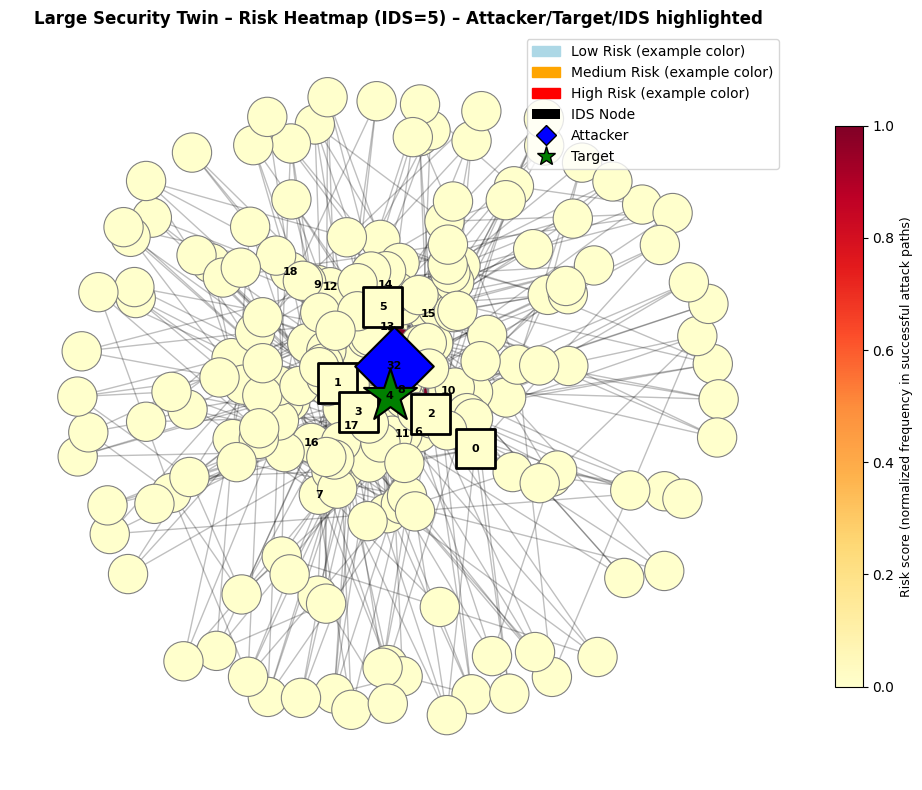

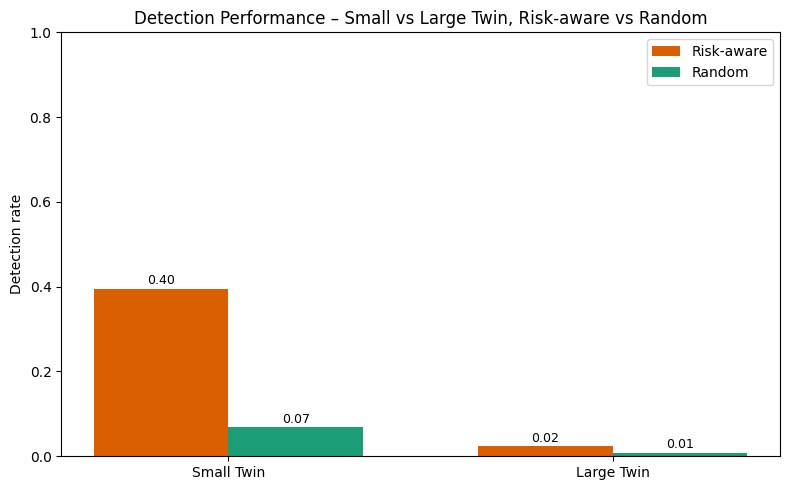


=== Summary ===
Small Twin: success_rate=0.012, detect(risk)=0.396, detect(rand)=0.069
Large Twin: success_rate=0.061, detect(risk)=0.024, detect(rand)=0.009
Visuals shown: Heatmaps (with Attacker/Target/IDS), Top risk nodes bar charts, and Detection comparison bar chart.


In [1]:

import random
import time
from collections import Counter
from typing import Dict, List, Tuple, Set, Optional

import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D


# Parameters (tune here)

SEED = 42
random.seed(SEED)

FAST_DEMO = False  # True => quick demo (smaller N, fewer sims)

# Simulation parameters
NUM_ATTACKS_SMALL = 2000 if FAST_DEMO else 5000
NUM_ATTACKS_LARGE = 4000 if FAST_DEMO else 10000

# IDS budgets
IDS_BUDGET_SMALL = 2
IDS_BUDGET_LARGE_PCT = 0.02  # 2% of nodes (rounded), min 5

# Large twin topology size
LARGE_N = 120 if FAST_DEMO else 220  # nodes
LARGE_M = 3                           # edges per new node in powerlaw cluster
LARGE_TRIADIC_P = 0.2                 # triadic closure probability

# Path discovery (for inspection)
K_SHORTEST_PATHS_TO_SHOW = 10
PATH_CUTOFF_SMALL = 6
PATH_CUTOFF_LARGE = 10

# Attack step limits
MAX_STEPS_SMALL = 25
MAX_STEPS_LARGE = 50

# Matplotlib style
plt.style.use("seaborn-v0_8-deep")


# Edge compromise probability model

def sample_edge_success_prob() -> float:

    x = random.random()
    y = random.random()
    val = (0.6 * x + 0.2 * y)  # concentrates around ~0.3–0.5
    return min(0.95, max(0.05, val))


# Twin builders

def build_small_twin() -> Tuple[nx.DiGraph, str, str, Dict[str, Tuple[float, float]]]:

    G = nx.DiGraph()
    nodes = ["Gateway", "LoadBalancer", "AppServerA", "AppServerB", "InternalSwitch", "Database"]
    edges = [
        ("Gateway", "LoadBalancer"),
        ("LoadBalancer", "AppServerA"),
        ("LoadBalancer", "AppServerB"),
        ("AppServerA", "InternalSwitch"),
        ("AppServerB", "InternalSwitch"),
        ("InternalSwitch", "Database"),
    ]
    G.add_nodes_from(nodes)
    for u, v in edges:
        G.add_edge(u, v, p_compromise=sample_edge_success_prob())
    attacker, target = "Gateway", "Database"
    pos = nx.spring_layout(G, seed=SEED)
    return G, attacker, target, pos

def build_large_twin(
    n: int = LARGE_N,
    m: int = LARGE_M,
    triadic_p: float = LARGE_TRIADIC_P,
    seed: int = SEED
) -> Tuple[nx.DiGraph, int, int, Dict[int, Tuple[float, float]]]:

    UG = nx.powerlaw_cluster_graph(n=n, m=m, p=triadic_p, seed=seed)

    attacker = min(UG.degree(), key=lambda x: x[1])[0]
    reachable = nx.single_source_shortest_path_length(UG, attacker)
    cand = sorted(reachable.items(), key=lambda x: (-UG.degree[x[0]], -x[1]))
    target = cand[0][0] if cand else max(UG.degree(), key=lambda x: x[1])[0]

    # Direct edges by BFS layers from attacker
    layer = dict(reachable)
    DG = nx.DiGraph()
    DG.add_nodes_from(UG.nodes())
    for u, v in UG.edges():
        du, dv = layer.get(u, 10**9), layer.get(v, 10**9)
        if du < dv:
            DG.add_edge(u, v, p_compromise=sample_edge_success_prob())
        elif dv < du:
            DG.add_edge(v, u, p_compromise=sample_edge_success_prob())
        else:
            # Same layer: prefer closer to target; else random
            try:
                du_t = nx.shortest_path_length(UG, u, target)
                dv_t = nx.shortest_path_length(UG, v, target)
            except nx.NetworkXNoPath:
                du_t = dv_t = 10**9
            if du_t < dv_t:
                DG.add_edge(u, v, p_compromise=sample_edge_success_prob())
            elif dv_t < du_t:
                DG.add_edge(v, u, p_compromise=sample_edge_success_prob())
            else:
                if random.random() < 0.5:
                    DG.add_edge(u, v, p_compromise=sample_edge_success_prob())
                else:
                    DG.add_edge(v, u, p_compromise=sample_edge_success_prob())

    # Ensure directed path exists
    if not nx.has_path(DG, attacker, target):
        descendants = nx.descendants(DG, attacker)
        if descendants:
            target = max(descendants, key=lambda x: DG.degree(x))
        else:
            hub = max(DG.degree(), key=lambda x: x[1])[0]
            DG.add_edge(attacker, hub, p_compromise=sample_edge_success_prob())
            target = hub

    pos = nx.spring_layout(DG, seed=seed, k=1.2 / (n ** 0.5))
    return DG, attacker, target, pos

# =========================
# Path discovery utilities
# =========================
def k_shortest_paths(G: nx.DiGraph, source, target, k: int = 10, cutoff: Optional[int] = None) -> List[List]:

    paths = []
    try:
        gen = nx.shortest_simple_paths(G, source, target)
        for p in gen:
            if cutoff is not None and len(p) > cutoff:
                continue
            paths.append(p)
            if len(paths) >= k:
                break
    except (nx.NetworkXNoPath, nx.NetworkXError):
        pass
    return paths

# =========================
# Attack simulation (Monte Carlo)
# =========================
def simulate_single_attack(G: nx.DiGraph, source, target, max_steps: int = 50) -> Tuple[bool, List]:

    current = source
    path = [current]
    visited = {current}
    steps = 0

    while current != target and steps < max_steps:
        succ = [v for v in G.successors(current) if v not in visited]
        if not succ:
            return False, path
        weights = [G[current][v].get('p_compromise', 0.5) for v in succ]
        nxt = random.choices(succ, weights=weights, k=1)[0]
        p = G[current][nxt].get('p_compromise', 0.5)
        if random.random() <= p:
            current = nxt
            path.append(current)
            visited.add(current)
            steps += 1
        else:
            return False, path
    return (current == target), path

def monte_carlo_attack_stats(
    G: nx.DiGraph, source, target, n_sims: int = 10000, max_steps: int = 50, count_only_success: bool = True
) -> Tuple[Dict, float, List[List], float]:

    t0 = time.time()
    node_counter = Counter()
    success_count = 0
    successful_paths_sample = []

    for _ in range(n_sims):
        success, path = simulate_single_attack(G, source, target, max_steps=max_steps)
        if success:
            success_count += 1
            for node in path:
                node_counter[node] += 1
            if len(successful_paths_sample) < 10:
                successful_paths_sample.append(path)
        else:
            if not count_only_success:
                for node in path:
                    node_counter[node] += 1

    denom = success_count if count_only_success else n_sims
    risk_scores = {node: (node_counter[node] / denom) if denom > 0 else 0.0 for node in G.nodes()}
    success_rate = success_count / n_sims if n_sims > 0 else 0.0
    t1 = time.time()
    return risk_scores, success_rate, successful_paths_sample, (t1 - t0)


# IDS placement strategies

def place_ids_risk_aware(risk_scores: Dict, k: int, exclude: Set) -> Set:
    eligible = [(n, s) for n, s in risk_scores.items() if n not in exclude]
    eligible.sort(key=lambda x: x[1], reverse=True)
    return set([n for n, _ in eligible[:max(0, k)]])

def place_ids_random(G: nx.DiGraph, k: int, exclude: Set) -> Set:
    candidates = [n for n in G.nodes() if n not in exclude]
    k = min(k, len(candidates))
    return set(random.sample(candidates, k)) if k > 0 else set()


# Detection evaluation

def evaluate_detection_rate(G: nx.DiGraph, source, target, ids_nodes: Set, n_sims: int = 5000, max_steps: int = 50) -> Tuple[float, float]:

    t0 = time.time()
    detected = 0
    for _ in range(n_sims):
        _, path = simulate_single_attack(G, source, target, max_steps=max_steps)
        if any(n in ids_nodes for n in path):
            detected += 1
    t1 = time.time()
    return (detected / n_sims if n_sims > 0 else 0.0), (t1 - t0)


# Utility: network stats + top risk

def print_network_stats(G: nx.DiGraph, title: str = "Network Statistics"):
    avg_deg = sum(dict(G.degree()).values()) / max(1, G.number_of_nodes())
    print(f"\n{title}")
    print(f"Nodes: {G.number_of_nodes()}")
    print(f"Edges: {G.number_of_edges()}")
    print(f"Average degree: {avg_deg:.2f}")

def show_top_risk_nodes_bar(risk_scores: Dict, top_k: int = 5, title: str = "Top Risk Nodes"):
    top_nodes = sorted(risk_scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
    print("\nTop Risk Nodes")
    for node, score in top_nodes:
        print(node, round(score, 3))
    names = [str(n) for n, _ in top_nodes]
    vals = [v for _, v in top_nodes]
    plt.figure(figsize=(6, 4))
    plt.bar(names, vals, color="#d95f02")
    plt.title(title)
    plt.ylabel("Risk Score")
    plt.tight_layout()
    plt.show()

# Visualization (Heatmap + Highlights + Legend + Optional Path)

def draw_risk_heatmap(
    G: nx.DiGraph,
    risk_scores: Dict,
    ids_nodes: Set,
    source,
    target,
    title: str,
    pos: Optional[Dict] = None,
    annotate: bool = True,
    label_top_k: int = 20,
    attack_path: Optional[List] = None
):

    fig, ax = plt.subplots(figsize=(10, 8))
    if pos is None:
        pos = nx.spring_layout(G, seed=SEED)

    # Normalize risk
    max_risk = max(risk_scores.values()) if risk_scores else 1.0
    norm = Normalize(vmin=0.0, vmax=max_risk if max_risk > 0 else 1.0)
    cmap = matplotlib.colormaps.get_cmap('YlOrRd')

    # Colors/sizes
    values = [risk_scores.get(n, 0.0) for n in G.nodes()]
    node_colors = [cmap(norm(val)) for val in values]
    node_sizes = [800 + 2200 * (val / (max_risk if max_risk > 0 else 1.0)) for val in values]

    # Base edges and nodes
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, arrows=True, arrowstyle='-|>', arrowsize=10, width=1.0)
    nx.draw_networkx_nodes(
        G, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
        node_shape='o', edgecolors='gray', linewidths=0.8
    )

    # Optional: highlight an example attack path (edges in red) — draw after base to be visible
    if attack_path and len(attack_path) >= 2:
        edges = list(zip(attack_path[:-1], attack_path[1:]))
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges, edge_color="red", width=3, arrows=True)

    # IDS nodes (squares with black border) — draw after base nodes to appear on top
    if ids_nodes:
        size_map = {n: s for n, s in zip(G.nodes(), node_sizes)}
        ids_colors = [cmap(norm(risk_scores.get(n, 0.0))) for n in ids_nodes]
        ids_sizes = [size_map.get(n, 1200) for n in ids_nodes]
        nx.draw_networkx_nodes(
            G, pos, ax=ax, nodelist=list(ids_nodes),
            node_color=ids_colors, node_size=ids_sizes,
            node_shape='s', edgecolors='black', linewidths=2.0
        )

    # Attacker (blue diamond) and Target (green star) — draw last to ensure visibility
    nx.draw_networkx_nodes(
        G, pos, ax=ax, nodelist=[source], node_color="blue",
        node_size=1600, node_shape="D", edgecolors="black", linewidths=1.5
    )
    nx.draw_networkx_nodes(
        G, pos, ax=ax, nodelist=[target], node_color="green",
        node_size=1600, node_shape="*", edgecolors="black", linewidths=1.5
    )

    # Labels: all for small; top-K for large
    if annotate:
        if len(G) <= label_top_k:
            nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_weight='bold')
        else:
            top_risk = sorted(risk_scores.items(), key=lambda x: x[1], reverse=True)[:label_top_k]
            sublabels = {n: str(n) for n, _ in top_risk}
            nx.draw_networkx_labels(G, pos, labels=sublabels, ax=ax, font_size=8, font_weight='bold')

    # Colorbar
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.75)
    cbar.set_label('Risk score (normalized frequency in successful attack paths)', fontsize=9)

    # Legend (risk explainers + IDS + attacker/target)
    legend_elements = [
        mpatches.Patch(color='lightblue', label='Low Risk (example color)'),
        mpatches.Patch(color='orange', label='Medium Risk (example color)'),
        mpatches.Patch(color='red', label='High Risk (example color)'),
        mpatches.Patch(facecolor='black', label='IDS Node'),
        Line2D([0], [0], marker='D', color='w', label='Attacker', markerfacecolor='blue',
               markeredgecolor='black', markersize=10, linestyle='None'),
        Line2D([0], [0], marker='*', color='w', label='Target', markerfacecolor='green',
               markeredgecolor='black', markersize=14, linestyle='None'),
    ]
    ax.legend(handles=legend_elements, loc="best")

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_axis_off()
    fig.tight_layout()
    plt.show()


# Detection comparison bar

def plot_detection_comparison_bar(results: Dict[str, Dict[str, float]], title: str = "Detection Rate Comparison"):

    fig, ax = plt.subplots(figsize=(8, 5))
    categories = list(results.keys())
    x = range(len(categories))
    width = 0.35

    vals_risk = [results[c].get('Risk-aware', 0.0) for c in categories]
    vals_rand = [results[c].get('Random', 0.0) for c in categories]

    ax.bar([xi - width/2 for xi in x], vals_risk, width=width, label='Risk-aware', color='#d95f02')
    ax.bar([xi + width/2 for xi in x], vals_rand, width=width, label='Random', color='#1b9e77')

    ax.set_xticks(list(x))
    ax.set_xticklabels(categories)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Detection rate')
    ax.set_title(title)

    for xi, v in zip([xi - width/2 for xi in x], vals_risk):
        ax.text(xi, v + 0.01, f"{v:.2f}", ha='center', fontsize=9)
    for xi, v in zip([xi + width/2 for xi in x], vals_rand):
        ax.text(xi, v + 0.01, f"{v:.2f}", ha='center', fontsize=9)

    ax.legend()
    fig.tight_layout()
    plt.show()


# Orchestrator (experiment)

def run_experiment():
    print("\n=== Security Twin IDS Placement Experiment ===")
    print(f"Random seed: {SEED}")
    print(f"FAST_DEMO: {FAST_DEMO}")

    # ---------- SMALL TWIN ----------
    print("\n[1] Building small twin...")
    small_G, small_src, small_tgt, small_pos = build_small_twin()
    print(f"   Attacker: {small_src}  |  Target: {small_tgt}")
    print_network_stats(small_G, title="[Small] Network Statistics")

    print("[1a] Discovering attack paths (k-shortest)...")
    small_paths = k_shortest_paths(small_G, small_src, small_tgt, k=K_SHORTEST_PATHS_TO_SHOW, cutoff=PATH_CUTOFF_SMALL)
    if small_paths:
        print(f"   Found {len(small_paths)} path(s) (showing up to {K_SHORTEST_PATHS_TO_SHOW}):")
        for i, p in enumerate(small_paths[:K_SHORTEST_PATHS_TO_SHOW], 1):
            print(f"     {i:2d}: {' -> '.join(map(str, p))}")
    else:
        print("   No paths found.")

    print("[1b] Monte Carlo simulation on small twin...]")
    small_risk, small_success_rate, small_success_samples, small_runtime = monte_carlo_attack_stats(
        small_G, small_src, small_tgt, n_sims=NUM_ATTACKS_SMALL, max_steps=MAX_STEPS_SMALL, count_only_success=True
    )
    print(f"   Success rate: {small_success_rate:.3f}")
    print(f"   Simulation time: {small_runtime:.2f} seconds")

    # IDS placement
    ids_budget_small = IDS_BUDGET_SMALL
    exclude_small = {small_src, small_tgt}
    ids_small_risk = place_ids_risk_aware(small_risk, ids_budget_small, exclude_small)
    ids_small_rand = place_ids_random(small_G, ids_budget_small, exclude_small)
    print(f"   IDS budget (small): {ids_budget_small}  | Risk-aware: {ids_small_risk}  | Random: {ids_small_rand}")

    # Detection evaluation with runtime
    print("[1c] Evaluating detection (small)...")
    det_small_risk, det_small_risk_time = evaluate_detection_rate(
        small_G, small_src, small_tgt, ids_small_risk, n_sims=max(500, NUM_ATTACKS_SMALL // 2), max_steps=MAX_STEPS_SMALL
    )
    det_small_rand, det_small_rand_time = evaluate_detection_rate(
        small_G, small_src, small_tgt, ids_small_rand, n_sims=max(500, NUM_ATTACKS_SMALL // 2), max_steps=MAX_STEPS_SMALL
    )
    print(f"   Detection (risk-aware): {det_small_risk:.3f} (time {det_small_risk_time:.2f}s) | "
          f"Detection (random): {det_small_rand:.3f} (time {det_small_rand_time:.2f}s)")

    # Top risk nodes (print + bar)
    show_top_risk_nodes_bar(small_risk, top_k=5, title="[Small] Top Risk Nodes")

    # Heatmap + highlights + optional example attack path
    small_example_path = small_success_samples[0] if small_success_samples else None
    draw_risk_heatmap(
        small_G, small_risk, ids_small_risk, small_src, small_tgt,
        title="Small Security Twin – Risk Heatmap (Attacker/Target/IDS highlighted)",
        pos=small_pos, annotate=True, label_top_k=20, attack_path=small_example_path
    )

    # LARGE TWIN
    print("\n[2] Building large twin...")
    large_G, large_src, large_tgt, large_pos = build_large_twin(n=LARGE_N, m=LARGE_M, triadic_p=LARGE_TRIADIC_P, seed=SEED)
    print(f"   Attacker: {large_src}  |  Target: {large_tgt}  | Nodes: {large_G.number_of_nodes()}  | Edges: {large_G.number_of_edges()}")
    print_network_stats(large_G, title="[Large] Network Statistics")

    print("[2a] Discovering attack paths (k-shortest, limited cutoff)...")
    large_paths = k_shortest_paths(large_G, large_src, large_tgt, k=K_SHORTEST_PATHS_TO_SHOW, cutoff=PATH_CUTOFF_LARGE)
    if large_paths:
        print(f"   Found {len(large_paths)} candidate path(s) (showing few):")
        for i, p in enumerate(large_paths[:min(3, K_SHORTEST_PATHS_TO_SHOW)], 1):
            print(f"     {i:2d}: {' -> '.join(map(str, p))}")
        if len(large_paths) > 3:
            print("     ...")
    else:
        print("   No short simple paths found (Monte Carlo will still sample).")

    print("[2b] Monte Carlo simulation on large twin...]")
    large_risk, large_success_rate, large_success_samples, large_runtime = monte_carlo_attack_stats(
        large_G, large_src, large_tgt, n_sims=NUM_ATTACKS_LARGE, max_steps=MAX_STEPS_LARGE, count_only_success=True
    )
    print(f"   Success rate: {large_success_rate:.3f}")
    print(f"   Simulation time: {large_runtime:.2f} seconds")

    # IDS placement
    ids_budget_large = max(5, round(IDS_BUDGET_LARGE_PCT * large_G.number_of_nodes()))
    exclude_large = {large_src, large_tgt}
    ids_large_risk = place_ids_risk_aware(large_risk, ids_budget_large, exclude_large)
    ids_large_rand = place_ids_random(large_G, ids_budget_large, exclude_large)
    print(f"   IDS budget (large): {ids_budget_large}  | Risk-aware: {len(ids_large_risk)} nodes  | Random: {len(ids_large_rand)} nodes")

    # Detection evaluation with runtime
    print("[2c] Evaluating detection (large)...")
    det_large_risk, det_large_risk_time = evaluate_detection_rate(
        large_G, large_src, large_tgt, ids_large_risk, n_sims=max(1000, NUM_ATTACKS_LARGE // 2), max_steps=MAX_STEPS_LARGE
    )
    det_large_rand, det_large_rand_time = evaluate_detection_rate(
        large_G, large_src, large_tgt, ids_large_rand, n_sims=max(1000, NUM_ATTACKS_LARGE // 2), max_steps=MAX_STEPS_LARGE
    )
    print(f"   Detection (risk-aware): {det_large_risk:.3f} (time {det_large_risk_time:.2f}s) | "
          f"Detection (random): {det_large_rand:.3f} (time {det_large_rand_time:.2f}s)")

    # Top risk nodes (print + bar)
    show_top_risk_nodes_bar(large_risk, top_k=5, title="[Large] Top Risk Nodes")

    # Heatmap + highlights + optional example attack path
    large_example_path = large_success_samples[0] if large_success_samples else None
    draw_risk_heatmap(
        large_G, large_risk, ids_large_risk, large_src, large_tgt,
        title=f"Large Security Twin – Risk Heatmap (IDS={ids_budget_large}) – Attacker/Target/IDS highlighted",
        pos=large_pos, annotate=True, label_top_k=20, attack_path=large_example_path
    )

    #  COMPARISON BAR
    results = {
        'Small Twin': {'Risk-aware': det_small_risk, 'Random': det_small_rand},
        'Large Twin': {'Risk-aware': det_large_risk, 'Random': det_large_rand},
    }
    plot_detection_comparison_bar(
        results, title="Detection Performance – Small vs Large Twin, Risk-aware vs Random"
    )

    #Summary
    print("\n=== Summary ===")
    print(f"Small Twin: success_rate={small_success_rate:.3f}, detect(risk)={det_small_risk:.3f}, detect(rand)={det_small_rand:.3f}")
    print(f"Large Twin: success_rate={large_success_rate:.3f}, detect(risk)={det_large_risk:.3f}, detect(rand)={det_large_rand:.3f}")
    print("Visuals shown: Heatmaps (with Attacker/Target/IDS), Top risk nodes bar charts, and Detection comparison bar chart.")


run_experiment()